# HD Integrated Visium Interactive Suite (HiVis) - Annotations and classifiers
This Notebook describes how to import annotations and pixel-classifiers from Qupath into HiVis.

We will use the HiVis object from [previous notebook]().

We will also use some plots, which will be covered in detail in next notebooks.

To see a details explanation and parameters for each function, visit the [documentation](https://hivis.readthedocs.io/en/latest/).


In [1]:
import os
import sys
from HiVis import HiVis

sys.path.append(os.path.abspath(".."))

path = 'output/mouse_intestine.pkl'
si = HiVis.load(path) 

## Work with pixel classifier
A classifier can also be a mask (image with the same dimension as the image that is stored in HiVis.image_fullres).
Detailed instructions for creating a pixel classifier can be found in the readme.

[Importing mask]


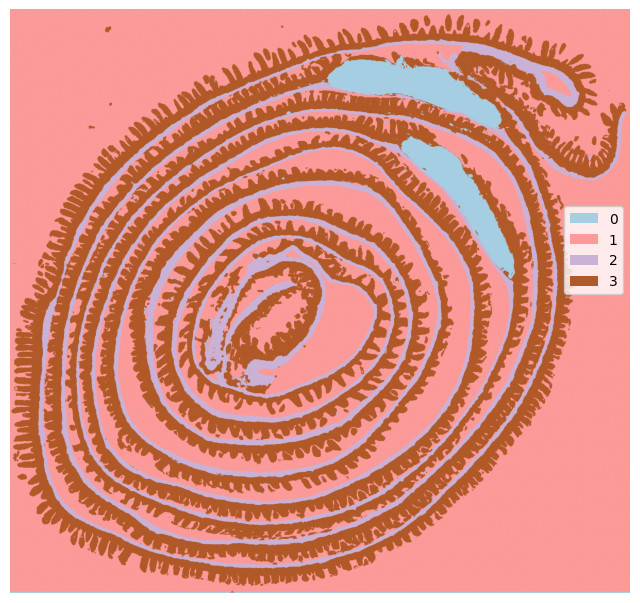

Assigning spots identity [muscle_villi_classifier]: 100%|██████████| 5367189/5367189 [00:33<00:00, 162184.35it/s]



To rename the values in the metadata, call the [update_meta] method with [muscle_villi_classifier] and dictionary with current_name:new_name


In [2]:
classifier_path = r"qupath\pixel_classifier_immune_muscle.tif"
classifier_name = "muscle_villi_classifier"

mask_values = si.add_mask(classifier_path, classifier_name, plot=True)

****

We can now rename the values

In [3]:
values = {0:"immune", 1:"lumen", 2:"muscle", 3:"tissue"}
si.update_meta(classifier_name, values)

And visualize the results

<Axes: title={'center': 'muscle_villi_classifier'}, xlabel='Spatial 1 (µm)', ylabel='Spatial 2 (µm)'>

<Figure size 640x480 with 0 Axes>

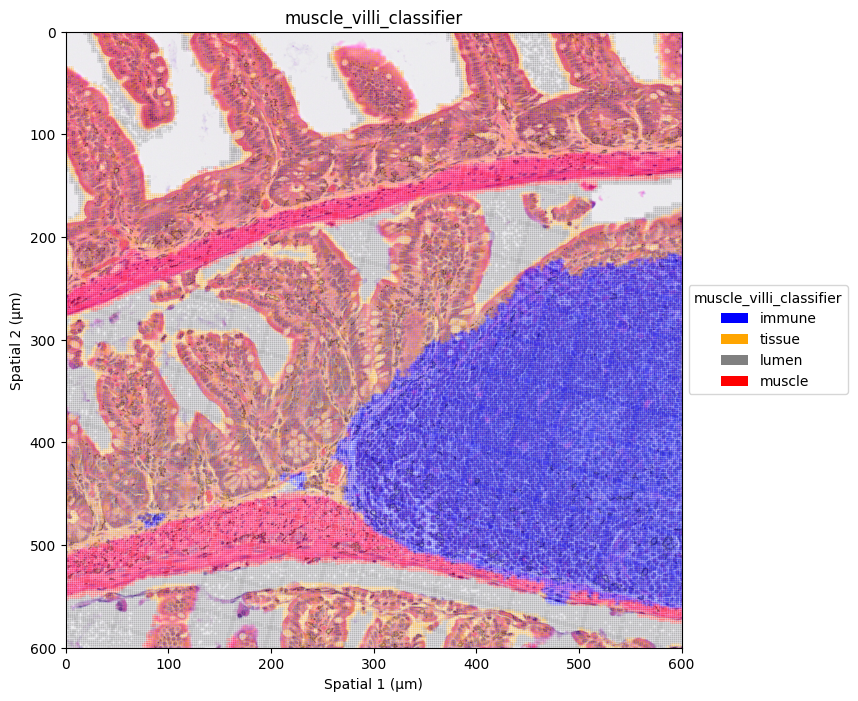

In [4]:
colors = {"immune":"blue", "lumen":"gray", "muscle":"red", "tissue":"orange"}
si.plot.spatial("muscle_villi_classifier", xlim=[3000,3600], ylim=[300,900], cmap=colors, alpha=0.15)

## Work with annotations
Annotations can be directly exported from Qupath as geojson ("File" -> "Export objects as GeoJSON")

In [5]:
annotation_path = r"qupath\annotation.geojson"
annotation_name = "intestine_part"

mask_values = si.add_annotations(annotation_path, annotation_name)

No measurements found


<Axes: title={'center': 'intestine_part'}, xlabel='Spatial 1 (µm)', ylabel='Spatial 2 (µm)'>

<Figure size 640x480 with 0 Axes>

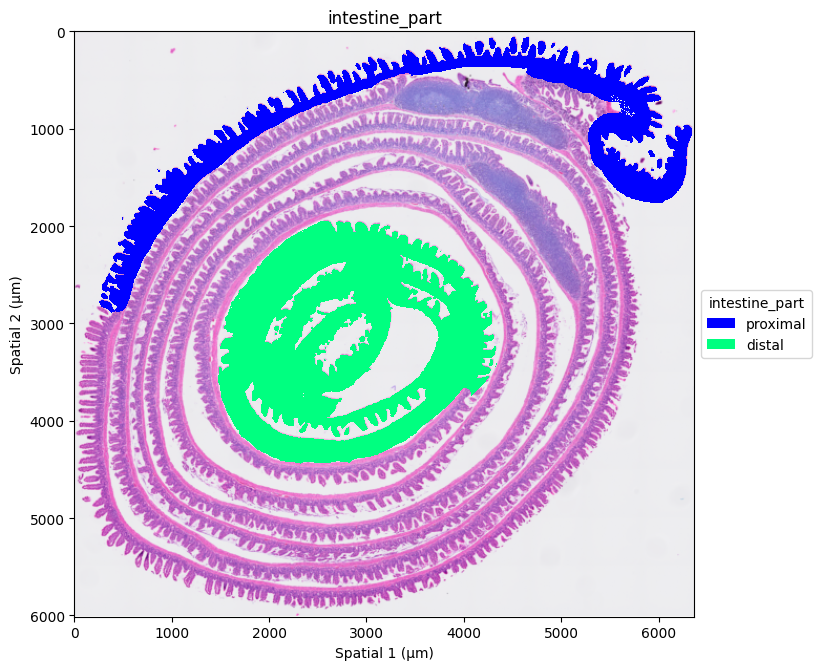

In [6]:
si.plot.spatial(annotation_name)

We can access the type and id of annotation (id is unique for each, independently of type)

In [7]:
si.adata.obs[[annotation_name,annotation_name + "_id"]].dropna().head()

,intestine_part,intestine_part_id
s_002um_02701_03218-1,proximal,853f7ed8-b245-4ed6-930d-fbc98a695e23
s_002um_01433_01112-1,distal,3ca5818f-ee25-4f55-90b8-fd0ae6b24a49
s_002um_01596_01155-1,distal,3ca5818f-ee25-4f55-90b8-fd0ae6b24a49
s_002um_01867_02041-1,distal,3ca5818f-ee25-4f55-90b8-fd0ae6b24a49
s_002um_02420_00448-1,proximal,853f7ed8-b245-4ed6-930d-fbc98a695e23


We can further aggregate the spots to an Aggregation object.
This will allow working on the objects and not the bins, as well as various analysis and plotting methods.
This is similar to aggregating the bins into single-cells, except here we have objects instead of cells.

For detailed explanation about the Aggregation object - please follow [notebooks 3-5](https://github.com/roynov01/HiVis/tree/main/tutorials).

In [8]:
si.agg_from_annotations("intestine_part_id",name="intestine_part",geojson_path=annotation_path,obs2agg=[])

Aggregating spots expression: 100%|██████████| 2/2 [00:00<00:00,  6.14it/s]


[Importing geometry]


<Axes: title={'center': 'intestine_part'}, xlabel='Spatial 1 (µm)', ylabel='Spatial 2 (µm)'>

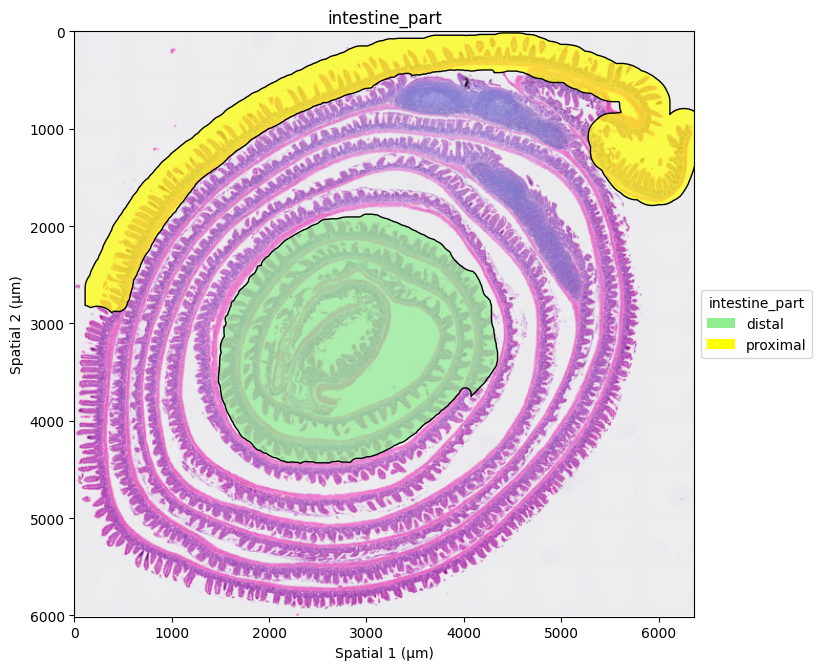

In [9]:
si.agg["intestine_part"].plot.cells("intestine_part",cmap=["lightgreen","yellow"])

In [10]:
si.save()

SAVING [mouse_intestine]


'output/mouse_intestine.pkl'